Just getting started on some analysis testing! - Aidan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("CleanedData.csv")
df.head()

,ResponseId,PID,HS_1,HS_2,HS_3,FM_1,FM_2,GM_1,GM_2,Dif_import1,Dif_import2,Dif_impos1,Dif_impos2,Country,Age,Sex,Ethnicity,Language
0,R_rr0W1Eib65n6Oxr,64469d49bd962313f4ecdb1f,6,6,6,2,3,4,4,2,2,3,2,GER,22,Female,White,German
1,R_O8SJG906vuCGx7X,643850d960ae67c75c0198df,1,5,5,4,2,4,5,4,5,2,2,GER,25,Male,White,English
2,R_6WqWfxshvfqOtYl,6408c1b54a500c8d81f12d6e,2,3,4,4,5,6,5,5,4,5,3,GER,24,Male,White,German
3,R_2uWzbfJ5XsTAZCw,61111091292799d97f76a5a3,2,3,2,3,3,4,4,5,5,2,2,GER,19,Female,White,German
4,R_3rsbkruurP6IEXT,6438576b1860de7fc057113d,3,2,5,1,1,5,6,2,3,5,4,GER,18,Female,White,German


In [5]:
len(df)

853

In [4]:
df["Country"].value_counts()

Country
USA    150
SAF    149
MEX    141
SPA    137
UNK    120
GER    104
SCA     52
Name: count, dtype: int64

Creating group columns 

In [6]:
df["help_seeking"] = df[["HS_1", "HS_2", "HS_3"]].mean(axis=1)
df["fixed_mindset"] = df[["FM_1", "FM_2"]].mean(axis=1)
df["growth_mindset"] = df[["GM_1", "GM_2"]].mean(axis=1)

df["difficulty_important"] = df[["Dif_import1", "Dif_import2"]].mean(axis=1)
df["difficulty_impossible"] = df[["Dif_impos1", "Dif_impos2"]].mean(axis=1)

Means by country

In [7]:
df.groupby("Country")[[
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]].mean()

,growth_mindset,fixed_mindset,difficulty_important,difficulty_impossible,help_seeking
Country,,,,,
GER,3.649038,3.105769,3.543269,2.432692,3.448718
MEX,4.656028,2.570922,3.886525,2.606383,4.018913
SAF,4.842282,2.661074,4.208054,2.271812,4.035794
SCA,3.942308,2.769231,3.403846,2.173077,3.224359
SPA,4.014599,2.868613,3.503650,2.616788,3.807786
UNK,4.025000,2.725000,3.795833,2.333333,3.416667
USA,4.333333,2.606667,3.880000,2.396667,3.648889


some basic box plots

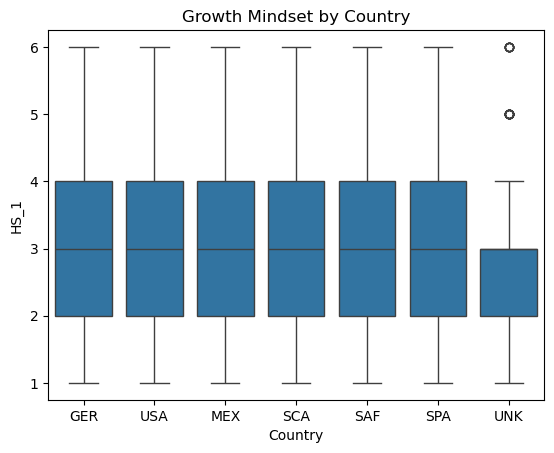

In [8]:
plt.figure()
sns.boxplot(data=df, x="Country", y="HS_1")
plt.title("Growth Mindset by Country")
plt.show()

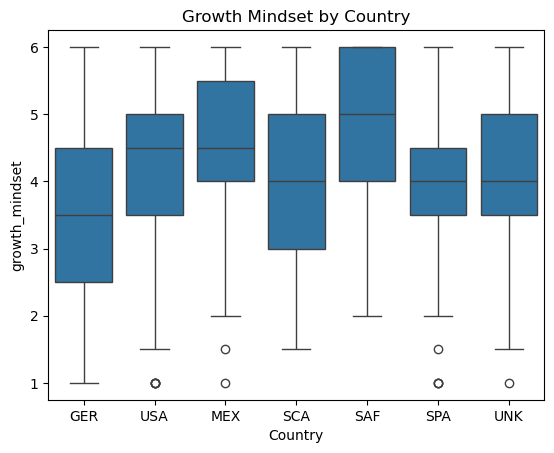

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(data=df, x="Country", y="growth_mindset")
plt.title("Growth Mindset by Country")
plt.show()

bit of an issue with the names here...

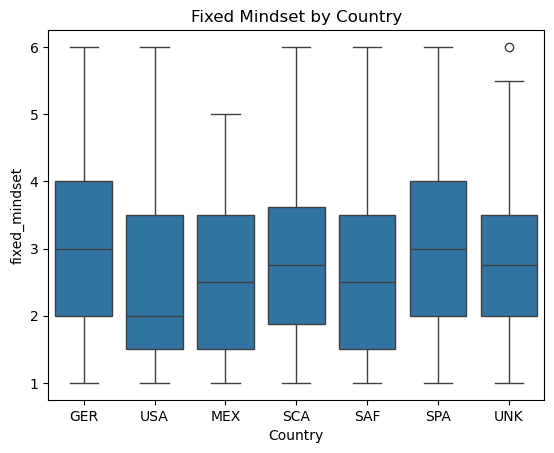

In [10]:
plt.figure()
sns.boxplot(data=df, x="Country", y="fixed_mindset")
plt.title("Fixed Mindset by Country")
plt.show()

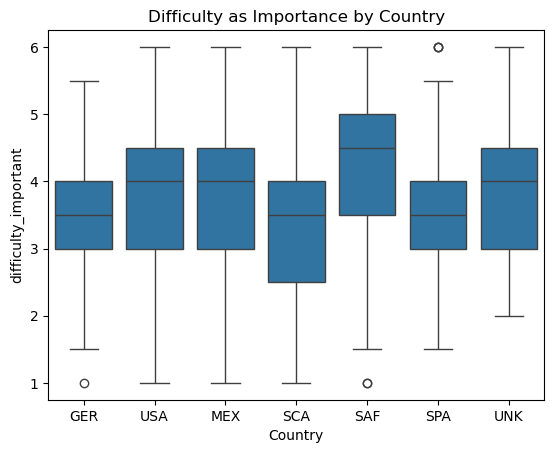

In [11]:
plt.figure()
sns.boxplot(data=df, x="Country", y="difficulty_important")
plt.title("Difficulty as Importance by Country")
plt.show()

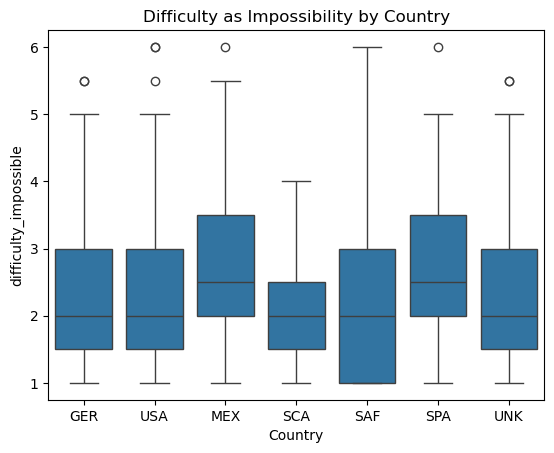

In [12]:
plt.figure()
sns.boxplot(data=df, x="Country", y="difficulty_impossible")
plt.title("Difficulty as Impossibility by Country")
plt.show()

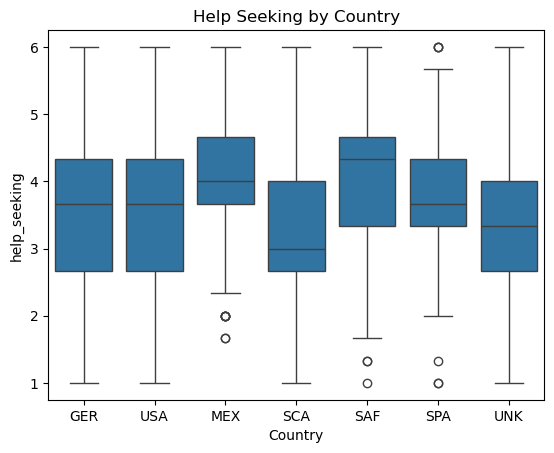

In [13]:
plt.figure()
sns.boxplot(data=df, x="Country", y="help_seeking")
plt.title("Help Seeking by Country")
plt.show()

We probably need to do something to handle outliers here, perhaps? 

Also figuring out a cleaner way to present all of this: 

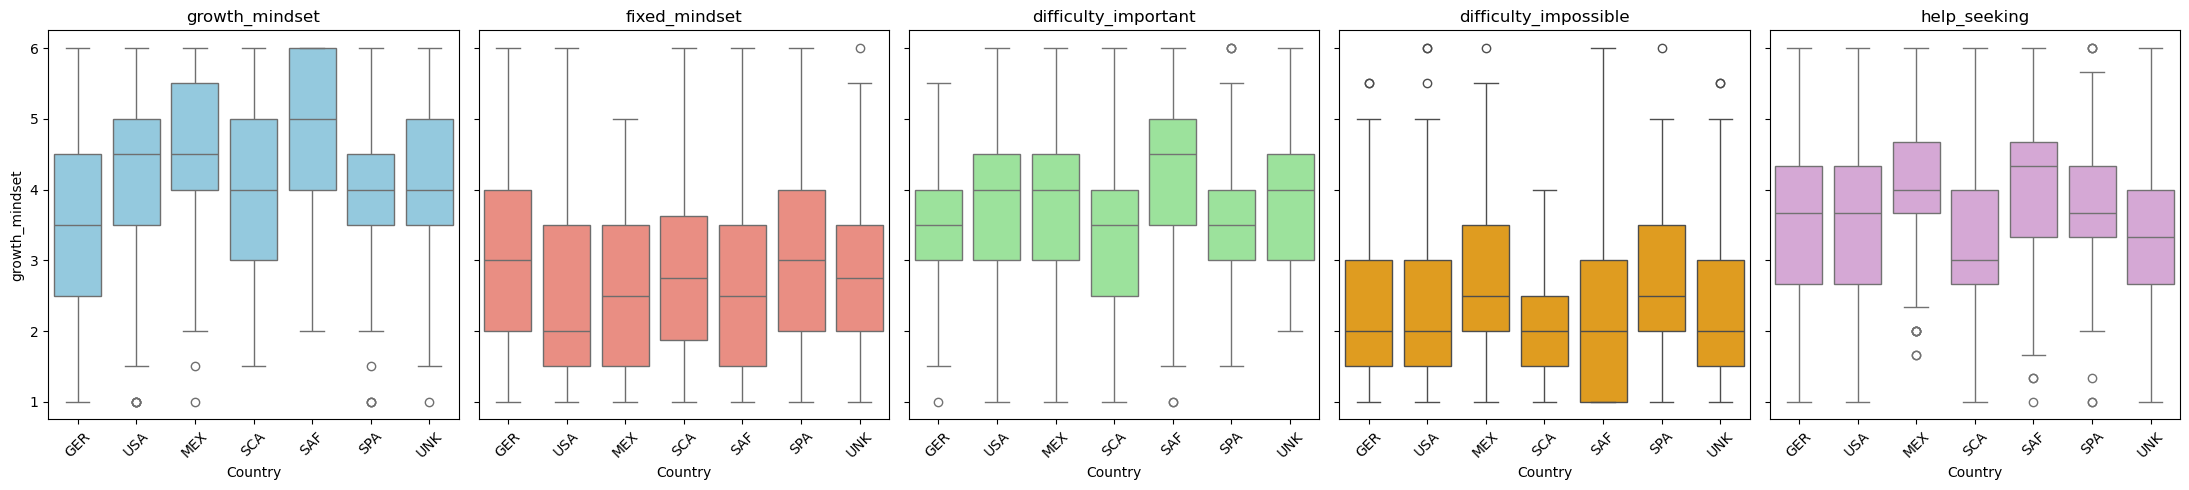

In [14]:
variables = [
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]

colors = ["skyblue", "salmon", "lightgreen", "orange", "plum"]

fig, axes = plt.subplots(1, len(variables), figsize=(22, 5), sharey=True)

for i, var in enumerate(variables):
    sns.boxplot(
        data=df,
        x="Country",
        y=var,
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Now moving on to some basic anova analysis

In [15]:
import scipy.stats as stats

variables = [
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]

for var in variables:
    groups = [group[var].dropna() for name, group in df.groupby("Country")]
    
    f_stat, p_val = stats.f_oneway(*groups)
    
    print(f"\n{var}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.6f}")


growth_mindset
F-statistic: 16.7492
p-value: 0.000000

fixed_mindset
F-statistic: 2.3695
p-value: 0.028196

difficulty_important
F-statistic: 7.9845
p-value: 0.000000

difficulty_impossible
F-statistic: 2.4494
p-value: 0.023566

help_seeking
F-statistic: 8.8392
p-value: 0.000000


In [16]:
import statsmodels.api as sm

X = df[["growth_mindset", "fixed_mindset", "help_seeking"]]
X = sm.add_constant(X)

y = df["difficulty_important"]

model = sm.OLS(y, X).fit(cov_type='HC3')  
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     difficulty_important   R-squared:                       0.090
Model:                              OLS   Adj. R-squared:                  0.087
Method:                   Least Squares   F-statistic:                     29.04
Date:                  Tue, 21 Apr 2026   Prob (F-statistic):           7.05e-18
Time:                          12:14:55   Log-Likelihood:                -1239.9
No. Observations:                   853   AIC:                             2488.
Df Residuals:                       849   BIC:                             2507.
Df Model:                             3                                         
Covariance Type:                    HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.560

In [17]:
import statsmodels.api as sm

X = df[["growth_mindset", "fixed_mindset", "help_seeking"]]
X = sm.add_constant(X)

y = df["difficulty_impossible"]

model = sm.OLS(y, X).fit(cov_type='HC3')  
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     difficulty_impossible   R-squared:                       0.142
Model:                               OLS   Adj. R-squared:                  0.139
Method:                    Least Squares   F-statistic:                     37.64
Date:                   Tue, 21 Apr 2026   Prob (F-statistic):           7.63e-23
Time:                           12:15:00   Log-Likelihood:                -1225.9
No. Observations:                    853   AIC:                             2460.
Df Residuals:                        849   BIC:                             2479.
Df Model:                              3                                         
Covariance Type:                     HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const         